# Challenge Part 2: Circuit QED

## 2.1

In [1]:
import dynamiqs as dq
import matplotlib.pyplot as plt
import jax.numpy as jnp
import scipy.constants as const

In [2]:
na, nb = 20, 5

# Given parameters (in Gigahertz)
omega_a_0 = 5.26
omega_b_0 = 7.70
phi_a = 0.06
phi_b = 0.29
e_J = 12.03
delta_e_J = 0.47
omega_d = 7.623
omega_p = 2.891
# eps_d = -3.815e-3
# eps_p = 0.122
kappa_a = 9.3e-3
kappa_b = 2.6

# New stuff (explicitly compute eps from paper)
g2_target = 0.763e-3
alpha_target = jnp.sqrt(5.0)
epsilon_p = 2*g2_target/(e_J * phi_a**2 * phi_b)
epsilon_d = -alpha_target**2 * jnp.conj(g2_target)

In [3]:
#initialization:
delta_a, delta_b = (0.0,0.0) # set initial AC Stark shifts to zero
omega_p = 2*omega_a_0 - omega_b_0 # initial frequency matching condition

#recursion loop to compute AC Stark shift:
rec_depth = 30
for i in range(rec_depth):
    #compute xi for mode a and b:
    alpha_1 = 1j*e_J*epsilon_p*phi_a / (kappa_a/2 + 1j*(omega_a_0 - omega_p))
    alpha_2 = 1j*e_J*epsilon_p*phi_a / (kappa_a/2 + 1j*(omega_a_0 + omega_p))

    beta_1 = 1j*e_J*epsilon_p*phi_b / (kappa_b/2 + 1j*(omega_b_0 - omega_p))
    beta_2 = 1j*e_J*epsilon_p*phi_b / (kappa_b/2 + 1j*(omega_b_0 + omega_p))

    pre = (jnp.real(alpha_1) + jnp.real(alpha_2)) * phi_a \
    + (jnp.real(beta_1) + jnp.real(beta_2)) * phi_b
    #compute AC Stark shifts:
    delta_a = 1/3*e_J * epsilon_p * phi_a**2 * pre 
    delta_b = 1/3*e_J * epsilon_p * phi_b**2 * pre 

    #recompute frequencies
    omega_a = omega_a_0 - 2*delta_e_J*phi_a**2 + delta_a 
    omega_b = omega_b_0 - 2*delta_e_J*phi_b**2 + delta_b 
    omega_p = 2*omega_a - omega_b

omega_d = omega_b

In [5]:
a, b = dq.destroy(na, nb)

H0 = omega_a * a.dag() @ a + omega_b * b.dag() @ b

phi_hat = phi_a * (a + a.dag()) + phi_b * (b + b.dag())
eps_sin = lambda t: -2 * e_J * jnp.sin(epsilon_p * jnp.cos(omega_p * t))
eps_cos = lambda t: 2 * delta_e_J * jnp.cos(epsilon_p * jnp.cos(omega_p * t))
H_ats = dq.modulated(eps_sin, phi_hat.sinm()) + \
        dq.modulated(eps_cos, phi_hat.cosm())
# H_ats_1 = dq.modulated(lambda t: -2 * Ej * eps_p * jnp.cos(omega_p * t), phi_hat) + \
#           dq.modulated(lambda t: Ej / 3 * eps_p * jnp.cos(omega_p * t), phi_hat @ phi_hat @ phi_hat)
# H_ats_2 = 2 * delta_Ej * dq.eye(na, nb) - delta_Ej * phi_hat @ phi_hat
# H_ats = H_ats_1 + H_ats_2

f = lambda t: 2 * epsilon_d * jnp.cos(omega_d * t)
H_d = dq.modulated(f, b + b.dag())

H = H0 + H_ats + H_d

/home/jovyan/.qbraid/environments/alice_g9lq38/pyenv/lib/python3.11/site-packages/equinox/_module.py:1096: UserWarning: A `SparseDIAQArray` has been converted to a `DenseQArray` while computing its matrix exponential.
  return self.__func__(self.__self__, *args, **kwargs)


In [6]:
psi0 = dq.fock((na, nb), (0, 0))


loss_ops = [jnp.sqrt(kappa_a) * a, jnp.sqrt(kappa_b) * b]

T = 100
t_save = jnp.linspace(0, T, 200)
res = dq.mesolve(H, loss_ops, psi0, t_save)

|████▍     |  44.0% ◆ elapsed 08m35s ◆ remaining 12m57s  

100%|██████████| 50/50 [00:05<00:00,  8.45it/s]


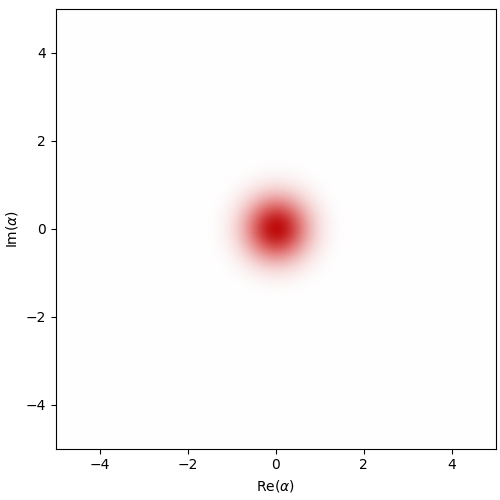

In [5]:
rho_a = dq.ptrace(res.states, 0)
dq.plot.wigner_gif(rho_a)

## 2.2

In [ ]:
def op_rot_displaced(t, op, omega_rot, dis):
    return op*jnp.exp(-1j*omega_rot*t) + dis * identity

def hamiltonian_rotating_displaced(t):

    #compute displacement fields
    alpha_t = alpha_1*jnp.exp(-1j*omega_p*t) + alpha_2*jnp.exp(1j*omega_p*t)
    beta_t = beta_1*jnp.exp(-1j*omega_p*t) + beta_2*jnp.exp(1j*omega_p*t)


    # the displaced rotating frame introduces a drive and detuning
    d_alpha_t = 1j*omega_p * (alpha_2*jnp.exp(1j*omega_p*t) - alpha_1*jnp.exp(-1j*omega_p*t))
    d_beta_t = 1j*omega_p * (beta_2*jnp.exp(1j*omega_p*t) - beta_1*jnp.exp(-1j*omega_p*t))


    #compute rotated displaced operators:
    omega_rot_a = ...
    omega_rot_b = ...
    a_f = op_rot_displaced(t, a, omega_rot_a, ...)
    adag_f = op_rot_displaced(t,
    b_f = 
    bdag_f =

    #displaced rotated phase operator
    phi_f = phi_a*(a_f + adag_f) + phi_b*(b_f + bdag_f)

    #linear term
    h_0 = omega_a_0 * adag_f @ a_f + omega_b_0 * bdag_f @ b_f
    
    #term from derivative of rotating frame
    h_rot = - omega_rot_a * dq.dag(a) @ a  - omega_rot_b * dq.dag(b) @ b
    
    #term from derivative of displaced frame
    h_dis =  -1j*(d_alpha_t*dq.dag(a)*jnp.exp(1j*omega_rot_a*t)-jnp.conj(d_alpha_t)*a*jnp.exp(-1j*omega_rot_a*t)) \
      - 1j*(d_beta_t*dq.dag(b)*jnp.exp(1j*omega_rot_b*t)-jnp.conj(d_beta_t)*b*jnp.exp(-1j*omega_rot_b*t))
        

    #ats term:
    sinterm = jnp.sin(eps_ats(t)) * dq.sinm(phi_f)
    costerm = jnp.cos(eps_ats(t)) * dq.cosm(phi_f)
    h_ats = - 2*e_J*sinterm +  2*delta_e_J*costerm 
    
    #drive on the buffer:
    # in the rotating frame, this term is non-rotating
    h_buffer_drive = jnp.conj(epsilon_d)*jnp.exp(1j*omega_d*t)*b_f \
        + epsilon_d * jnp.exp(-1j*omega_d*t) * bdag_f
    
    return h_0 + h_ats + h_buffer_drive + h_rot + h_dis

In [8]:
kappa_a = 9.3e-3
kappa_b = 2.6
a, b = dq.destroy(na, nb)

xi_a = -1.0j * Ej / (kappa_a / 2 + 1.0j * (omega_a - omega_p))
xi_b = -1.0j * Ej / (kappa_b / 2 + 1.0j * (omega_b - omega_p))
omega_a_shift = omega_a - Ej / 3 * phi_a**2 * (jnp.real(xi_a) * phi_a + jnp.real(xi_b) * phi_b)
omega_b_shift = omega_b - Ej / 3 * phi_b**2 * (jnp.real(xi_a) * phi_a + jnp.real(xi_b) * phi_b)
g2 = Ej * eps_p * phi_a**2 * phi_b

print("g2 =", g2)
print("eps_d =", eps_d)
print(omega_a_shift - (omega_p + omega_d) / 2)
print(omega_b_shift - omega_d)

H_rwa = (omega_a_shift - (omega_p + omega_d) / 2) * a.dag() @ a + \
        (omega_b_shift - omega_d) * b.dag() @ b + \
        jnp.conj(g2) * a @ a @ b.dag() + g2 * a.dag() @ a.dag() @ b
H_d = jnp.conj(eps_d) * b + eps_d * b.dag()
H = H_rwa + H_d

psi0 = dq.fock((na, nb), (0, 0))

loss_ops = [jnp.sqrt(kappa_a) * a, jnp.sqrt(kappa_b) * b]

T = 4
t_save = jnp.linspace(0, T, 200)
res = dq.mesolve(H, loss_ops, psi0, t_save)

g2 = 1.5322370399999996
eps_d = -3.815
17.871094
424.4048


|██████████| 100.0% ◆ elapsed 22.83s ◆ remaining 0.00ms  


100%|██████████| 50/50 [00:05<00:00,  8.90it/s]


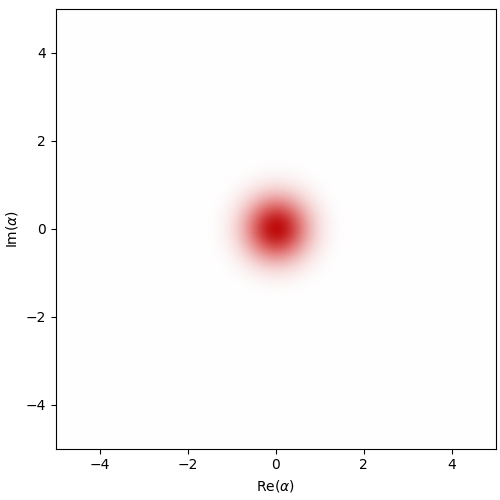

In [7]:
rho_a = dq.ptrace(res.states, 0)
dq.plot.wigner_gif(rho_a)

g2 = 0.00153223704
eps_d = -0.003815


|          |   0.0% ◆ elapsed 0.00ms ◆ remaining ?
|██████████| 100.0% ◆ elapsed 1.20s ◆ remaining 0.00ms     

100%|██████████| 50/50 [00:06<00:00,  7.22it/s]


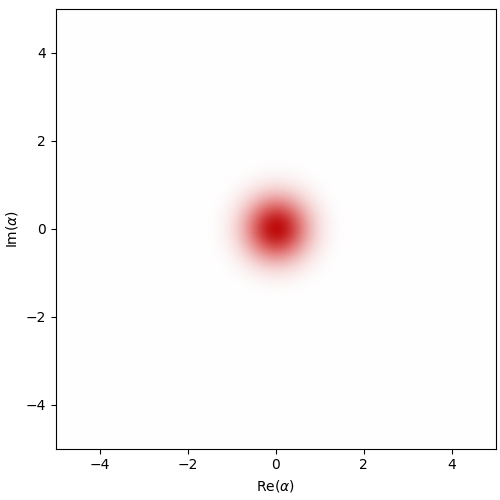

In [14]:
na, nb = 20, 5
omega_a = 5.26
omega_b = 7.70
phi_a = 0.06
phi_b = 0.29
Ej = 12.03
delta_Ej = 0.47
omega_d = 7.623
omega_p = 2.891
eps_d = -3.815e-3
eps_p = 0.122
kappa_a = 9.3e-6
kappa_b = 2.6e-3
a, b = dq.destroy(na, nb)



g2 = Ej * eps_p * phi_a**2 * phi_b
print("g2 =", g2)
print("eps_d =", eps_d)
H_2ph = jnp.conj(g2) * a @ a @ b.dag() + g2 * a.dag() @ a.dag() @ b
H_d = jnp.conj(eps_d) * b + eps_d * b.dag()
H = H_2ph + H_d

psi0 = dq.fock((na, nb), (0, 0))


loss_ops = [jnp.sqrt(kappa_a) * a, jnp.sqrt(kappa_b) * b]
T = 4e3
t_save = jnp.linspace(0, T, 100)
res = dq.mesolve(H, loss_ops, psi0, t_save)
rho_a = dq.ptrace(res.states, 0)
dq.plot.wigner_gif(rho_a)

|██████████| 100.0% ◆ elapsed 718.67ms ◆ remaining 0.00ms  


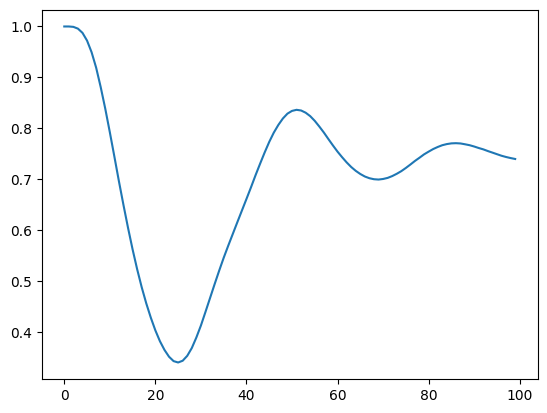

In [13]:
na, nb = 20, 5  # Hilbert space dimensions
T = 4.0  # Total simulation time
g2 = 1.0  # Two-photon coupling strength
eps_d = -4  # Drive amplitude
kappa_b = 10  # Decay rate
psi0 = dq.fock((na, nb), (0, 0))  # Initial state
a, b = dq.destroy(na, nb)
H_2ph = g2 * a.dag() @ a.dag() @ b + jnp.conj(g2) * a @ a @ b.dag()
H_d = jnp.conj(eps_d) * b + eps_d * b.dag()
H = H_2ph + H_d
loss_op = jnp.sqrt(kappa_b) * b
t_save = jnp.linspace(0, T, 100)
target_res = dq.mesolve(H, [loss_op], psi0, t_save)

plt.plot(dq.fidelity(res.states, target_res.states))